In [1]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 78.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 87.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 5.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=8e3a59da372947f22386285ef03da78465102787cb32514391c42779d55fb085
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


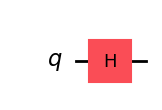

In [5]:

# Create a circuit with one qubit
circuit = QuantumCircuit(1)

# Add a Hadamard (H) gate on qubit 0, to create a superposition
circuit.h(0)

# Draw the circuit diagram. Delete "mpl" to get a text diagram.
circuit.draw("mpl")

In [6]:
# Now simulate the circuit by calculating the effect on state vectors.
# Set the initial state of the simulator to |0>
# The parameter 2 is because there are two basis states.
# For a two qubit system it would be 4, for a three qubit system it would be 8.
# The parameter 0 means we get the basis state corresponding to 0 in binary.
state = Statevector.from_int(0, 2)

# Apply the circuit to the state
state = state.evolve(circuit)

# Display using latex. This requires the pylatexenc module.
# Omit "latex" to get a numerical (not algebraic) view of the state vector.
state.draw("latex")

<IPython.core.display.Latex object>

In [7]:
# A different way of dislaying the state, again using latex
from qiskit.visualization import array_to_latex

array_to_latex(state)

<IPython.core.display.Latex object>

In [8]:
# The whole circuit is a unitary operator, which we can display.

U = Operator(circuit)
array_to_latex(U)

<IPython.core.display.Latex object>

In [9]:
# Or less beautifully:
U.data
# The format is a little bit odd. 0.j means the imaginary part is 0
# 0 is being displayed with a decimal point but no trailing 0
# j is used for the square root of -1, instead of i

array([[ 0.70710678+0.j,  0.70710678+0.j],
       [ 0.70710678+0.j, -0.70710678+0.j]])

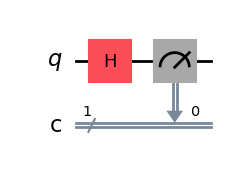

In [10]:
# Now reconstruct the circuit and add a measurement
# The second parameter of QuantumCircuit is the number of classical bits
circuit = QuantumCircuit(1,1)
circuit.h(0)

# The first list is the qubits to measure,
# the second list is the classical bits where the results go
circuit.measure([0],[0])
circuit.draw("mpl")

In [11]:
# We will need to transpile the circuit into QASM instructions for the back end

# Use BasicSimulator
backend = BasicSimulator()

# Compile / transpile
qc_compiled = transpile(circuit, backend)

# Run the circuit on the simulator.
# We've set the number of repeats of the circuit
# to be 1024, which is the default.
# The qubits start in state |0>
job_sim = backend.run(qc_compiled, shots=1024)

# Grab the results from the job (this doesn't produce any output).
result_sim = job_sim.result()

In [12]:
# The simplest way to see the results of the simulation
counts = result_sim.get_counts(qc_compiled)
print(counts)

# The results are not exactly half 0 and half 1, but should be close.
# There will be different results each time the previous cell is run.

{'1': 537, '0': 487}


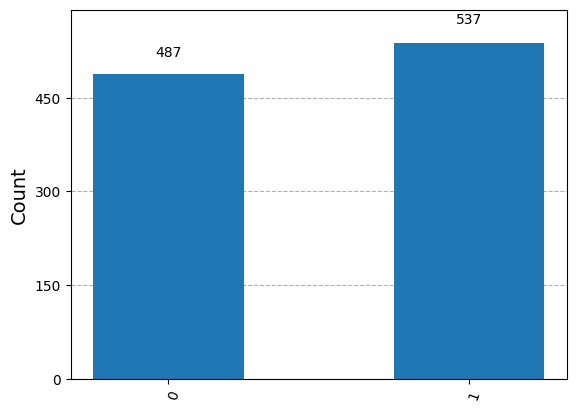

In [13]:
# We can also produce a graph

plot_histogram(counts)

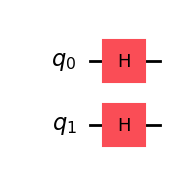

In [14]:
# Now let's move on to two qubits.
# Apply H to both qubits and see what we get.

circuit = QuantumCircuit(2)
circuit.h(0)
circuit.h(1)

circuit.draw("mpl")

In [15]:
state = Statevector.from_int(0, 4) # 4 is the number of basis states on 2 qubits
state = state.evolve(circuit)
state.draw("latex")

<IPython.core.display.Latex object>

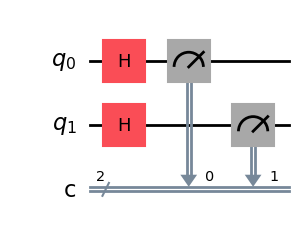

In [16]:
# Now measurement. This time we construct the measurement part
# of the circuit separately and then combine it with the first circuit.

# A new circuit with 2 qubits and 2 classical bits
meas = QuantumCircuit(2, 2)

# Map the quantum measurement to the classical bits
meas.measure(range(2), range(2))

# The Qiskit circuit object supports composition.
# Here the meas has to be first and front=True (putting it before)
# as compose must put a smaller circuit into a larger one.
qc = meas.compose(circuit, range(2), front=True)

qc.draw("mpl")

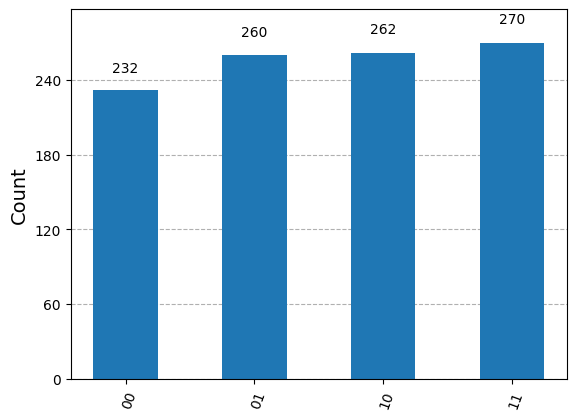

In [17]:
# Simulate again, using the same back end
qc_compiled = transpile(qc, backend)
job_sim = backend.run(qc_compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(qc_compiled)
plot_histogram(counts)

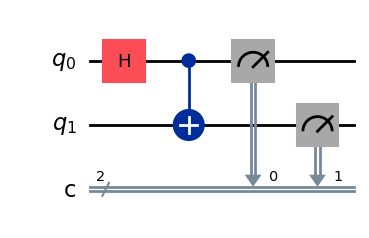

In [18]:
# Now for some entanglement.
# Construct a Bell state and measure both qubits to see that
# both measurements give the same result.

circuit = QuantumCircuit(2,2)
circuit.h(0)
circuit.cx(0,1) # cx means CNOT because it's a controlled version of x (negation)
circuit.measure(range(2),range(2))
circuit.draw("mpl")

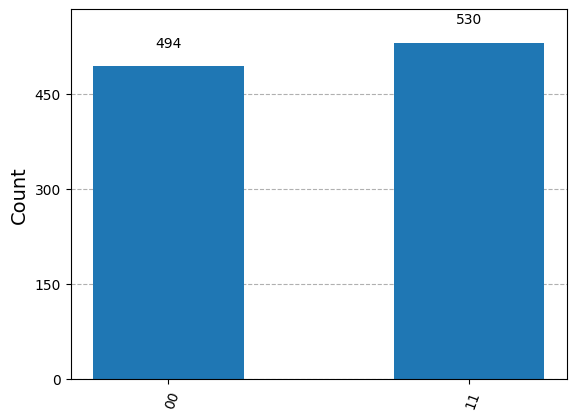

In [19]:
qc_compiled = transpile(circuit, backend)
job_sim = backend.run(qc_compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(qc_compiled)
plot_histogram(counts)

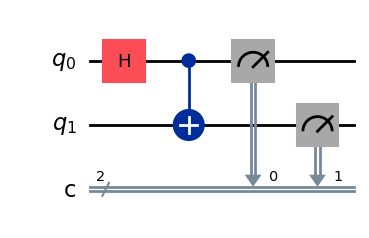

In [20]:
# EXERCISE

# Make a copy here of the circuit that creates the Bell state 1/sqrt(2) ( |00> + |11> ).

# Modify it to create the other Bell states: 1/sqrt(2) ( |00> - |11> ), 1/sqrt(2) ( |01> + |10> ), 1/sqrt(2) ( |01> - |10> ).

# You will need to use X and Z gates. Check that your circuit is correct by displaying the state vector in each case.

# For each of the Bell states, repeat the simulation with measurements and check that the results are as expected.

# circuit1 is the original Bell state, 1/sqrt(2) ( |00> + |11> ).

circuit1 = QuantumCircuit(2,2)
circuit1.h(0)
circuit1.cx(0,1) # cx means CNOT because it's a controlled version of x (negation)
circuit1.measure(range(2),range(2))
circuit1.draw("mpl")



In [21]:
# circuit1 is the original Bell state, 1/sqrt(2) ( |00> + |11> ).
# First construct the circuit (without classical bits) and use evolve to calculate the final state.

circuit1 = QuantumCircuit(2)
circuit1.h(0)
circuit1.cx(0,1) # cx means CNOT because it's a controlled version of x (negation)
state = Statevector.from_int(0, 4) # 4 is the number of basis states on 2 qubits
state = state.evolve(circuit1)
state.draw("latex")

<IPython.core.display.Latex object>

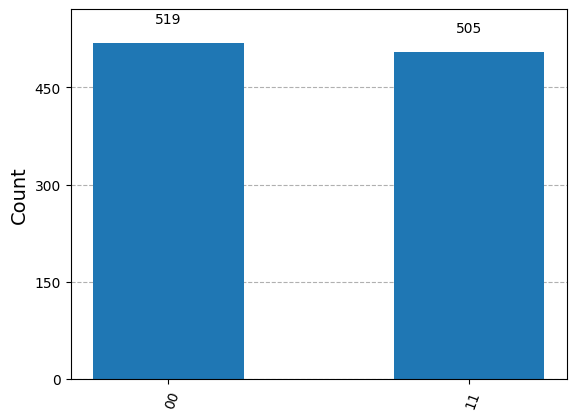

In [22]:
# circuit1 is the original Bell state, 1/sqrt(2) ( |00> + |11> ).
# Next construct the circuit with two classical bits so that we can add measurement
# and simulate.

circuit1 = QuantumCircuit(2,2)
circuit1.h(0)
circuit1.cx(0,1) # cx means CNOT because it's a controlled version of x (negation)
circuit1.measure(range(2),range(2))
qc_compiled = transpile(circuit1, backend)
job_sim = backend.run(qc_compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(qc_compiled)
plot_histogram(counts)


In [23]:
# circuit2 is 1/sqrt(2) ( |00> - |11> )

circuit2 = QuantumCircuit(2)
circuit2.h(0)
circuit2.cx(0,1) # cx means CNOT because it's a controlled version of x (negation)
circuit2.z(1) # to change the sign of the |11> part
state = Statevector.from_int(0, 4)
state = state.evolve(circuit2)
state.draw("latex")


<IPython.core.display.Latex object>

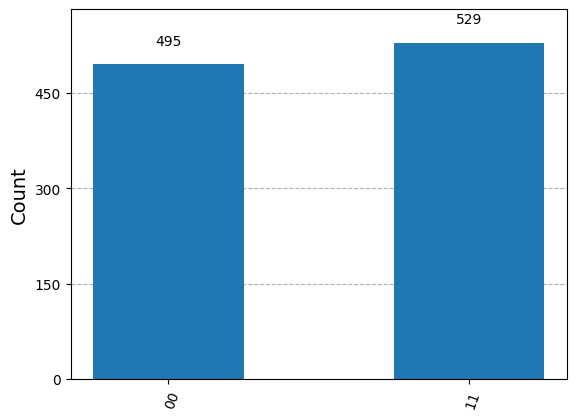

In [24]:
circuit2 = QuantumCircuit(2,2)
circuit2.h(0)
circuit2.cx(0,1) # cx means CNOT because it's a controlled version of x (negation)
circuit2.z(1)
circuit2.measure(range(2),range(2))
qc_compiled = transpile(circuit1, backend)
job_sim = backend.run(qc_compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(qc_compiled)
plot_histogram(counts)

In [ ]:
# circuit3 is 1/sqrt(2) ( |01> + |10> )

circuit3 = QuantumCircuit(2)
circuit3.h(0)
circuit3.cx(0,1) # cx means CNOT because it's a controlled version of x (negation)
circuit3.x(1) # to flip one of the qubits
state = Statevector.from_int(0, 4)
state = state.evolve(circuit3)
state.draw("latex")

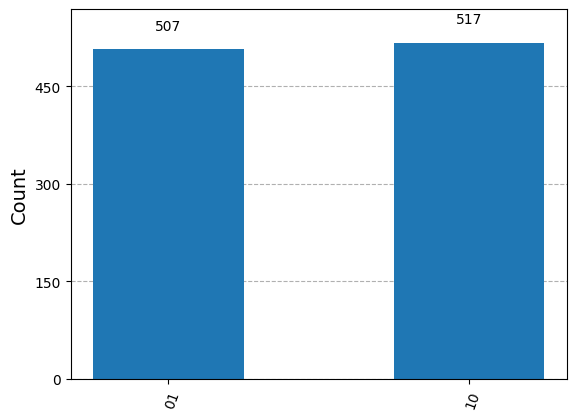

In [26]:
circuit3 = QuantumCircuit(2,2)
circuit3.h(0)
circuit3.cx(0,1) # cx means CNOT because it's a controlled version of x (negation)
circuit3.x(1) # to flip one of the qubits
circuit3.measure(range(2),range(2))
qc_compiled = transpile(circuit3, backend)
job_sim = backend.run(qc_compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(qc_compiled)
plot_histogram(counts)

In [28]:
# circuit4 is 1/sqrt(2) ( |01> - |10> )

circuit4 = QuantumCircuit(2)
circuit4.h(0)
circuit4.cx(0,1) # cx means CNOT because it's a controlled version of x (negation)
circuit4.x(1) # to flip one of the qubits
circuit4.z(1) # to change the sign of |10>
state = Statevector.from_int(0, 4)
state = state.evolve(circuit4)
state.draw("latex")

<IPython.core.display.Latex object>

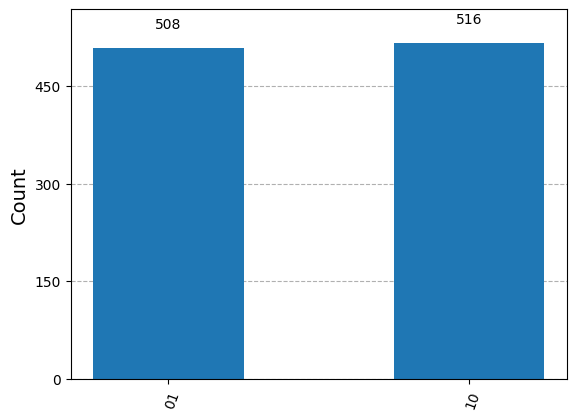

In [31]:
circuit4 = QuantumCircuit(2,2)
circuit4.h(0)
circuit4.cx(0,1) # cx means CNOT because it's a controlled version of x (negation)
circuit4.x(1) # to flip one of the qubits
circuit4.z(1) # to change the sign of |10>
circuit4.measure(range(2),range(2))
qc_compiled = transpile(circuit4, backend)
job_sim = backend.run(qc_compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(qc_compiled)
plot_histogram(counts)

In [ ]:
# EXERCISE

# The GHZ state on any number of qubits has the form  1/sqrt(2) ( |00...0> + |11...1> )

# The Bell state 1/sqrt(2) ( |00> + |11> ) is the case for two qubits.

# Write code to construct a circuit that produces a GHZ state for any given number of qubits.

# Try simulating the circuit, with measurements.

In [ ]:
n = 5
ghz = QuantumCircuit(n,n)
ghz.h(0)
for a in range(n-1):
  ghz.cx(a,a+1)
ghz.measure(range(n),range(n))

qc_compiled = transpile(ghz, backend)
job_sim = backend.run(qc_compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(qc_compiled)
plot_histogram(counts)

Constructing 1/sqrt(2)( |00> - |11> )



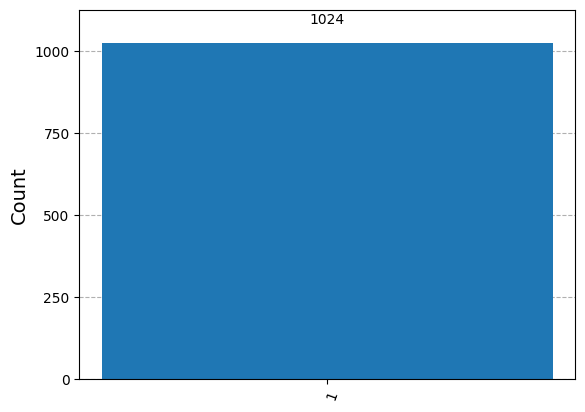

In [36]:
# EXERCISE

# Going back to the Bell states, notice that measurements of 1/sqrt(2)( |00> + |11> )  and  1/sqrt(2)( |00> - |11> ) give the same results.

# Can you find a way of using quantum operators and measurements to distinguish between these two states?

# Hint: first think about applying CNOT (that is, cx in Qiskit).

# Suppose we have a state that is either  1/sqrt(2)( |00> + |11> )  or  1/sqrt(2)( |00> - |11> )
# Let's write it as 1/sqrt(2)( |00> +- |11> )

# If we apply CNOT we get  1/sqrt(2)( |00> +- |10> )

# This is equal to 1/sqrt(2) (|0> +- |1>) |0>

# Now apply H to the first qubit.  1/sqrt(2) (|0> + |1>) becomes |0>, and 1/sqrt(2)(|0> - |1>) becomes |1>
# so our state becomes either |00> or |10>

# Now we can measure the first qubit and get either 0 or 1 definitely, depending on the state.
# If the result of this measurement is 0, the original state was 1/sqrt(2)( |00> + |11> ).
# If the result if 1, the original state was 1/sqrt(2)( |00> - |11> ).

# Now let's implement a demonstration of this idea.

import random

circuit = QuantumCircuit(2,1) # Two qubits, one classical bit, because we only need one measurement.
circuit.h(0)
circuit.cx(0,1)
if random.randint(0,1) == 0:
  circuit.z(1)
  print("Constructing 1/sqrt(2)( |00> - |11> )\n")
else:
  print("Constructing 1/sqrt(2)( |00> + |11> )\n")

circuit.cx(0,1)
circuit.h(0)
circuit.measure([0],[0])

circuit_compiled = transpile(circuit, backend)
job_sim = backend.run(circuit_compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(circuit_compiled)
plot_histogram(counts)

In [ ]:
# EXERCISE (don't worry if you don't get this far)

# The W state on three qubits is 1/sqrt(3)( |001> + |010> + |100> )

# To construct the W state we need two new operators.

# The first is controlled H, which is called ch in Qiskit.
# It's similar to CNOT (cx in Qiskit) but it applies H to the target qubit if the control qubit is |1>.

# The second is R_y, called ry in Qiskit.
# It's a kind of rotation and it has a parameter which is an angle.
# The angle we need is 2 * inverse cosine of 1/sqrt(3).

import math

# We can use the Qiskit call  ry(2*math.acos(1/math.sqrt(3)),qubit_number)

# The sequence of operations to construct the W state is as follows.

# Start with three qubits in state |000>

# Apply ry(2*math.acos(1/math.sqrt(3))) to qubit 0

# Apply ch with qubit 0 as control and qubit 1 as target

# Apply cx with qubit 1 as control and qubit 2 as target

# Apply cx with qubit 0 as control and qubit 1 as target

# Apply X to qubit 0

# Implement a circuit with these operations, use the symbolic display to check that it constructs the W state,
# then add measurements and check that the results of simulation are what you expect.
# Note that when producing the symbolic display, Qiskit numbers the qubits from right to left.

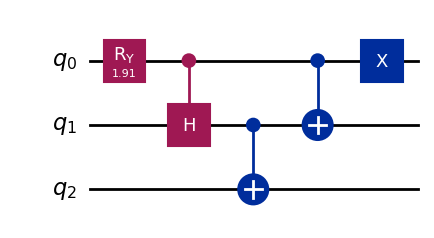

In [ ]:
# Construct the circuit and draw it

w_circuit = QuantumCircuit(3)
w_circuit.ry(2*math.acos(1/math.sqrt(3)),0)
w_circuit.ch(0,1)
w_circuit.cx(1,2)
w_circuit.cx(0,1)
w_circuit.x(0)

w_circuit.draw("mpl")

In [ ]:
# Calculate the state and display it symbolically

state = Statevector.from_int(0, 8)
state = state.evolve(w_circuit)
state.draw("latex")

<IPython.core.display.Latex object>

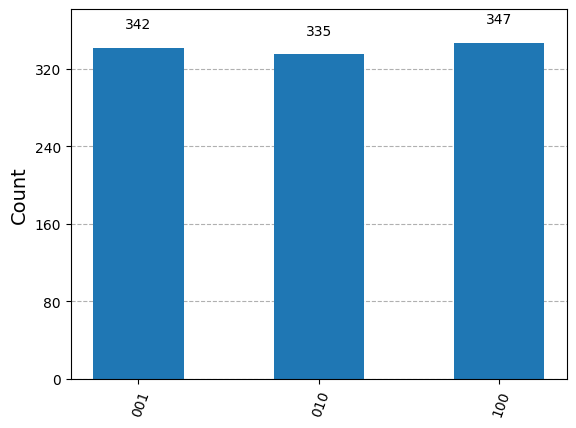

In [ ]:
# Construct the circuit again with three classical bits added, and add measurements

w_circuit = QuantumCircuit(3,3)
w_circuit.ry(2*math.acos(1/math.sqrt(3)),0)
w_circuit.ch(0,1)
w_circuit.cx(1,2)
w_circuit.cx(0,1)
w_circuit.x(0)
w_circuit.barrier()
w_circuit.measure([0,1,2],[0,1,2])

qc_compiled = transpile(w_circuit, backend)
job_sim = backend.run(qc_compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(qc_compiled)
plot_histogram(counts)